# **Business Case 1: Segmenting Clients**




In [30]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
import gower
import prince
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [31]:
# Load data in a DataFrame
path = "./Dataset1_BankClients.xlsx"
data = pd.read_excel(path)


In [32]:
# Drop the column by its actual name (e.g., 'ID' or the actual name of the column)
data = data.drop(columns=['ID'])  # Replace 'ID' with the actual column name to drop

# Let's inspect the first 5 record
data.head()



,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2


# Preparing data
We extract the variables of interest, also dividing into:
* **Numerical**.
* **Categorical** (excluding the ID, which is not informative at this level).


We have to:
* **Encode categorical variables**, so that they can be digestible by clustering algorithms - they are all trasformed in boolean variables by one-hot encoding.
* **Normalize** in [0, 1] numerical variables.

## Outlier Analysis

In [33]:
def find_outliers_selective(df, columns_to_check):
    """
    df: Your pandas DataFrame
    columns_to_check: List of strings (names of continuous numerical columns)
    """
    rows_to_drop = set()
    
    for col in columns_to_check:
        data = df[col].values
        mean, std = data.mean(), data.std()
        
        # 3-sigma rule
        lower, upper = mean - 3*std, mean + 3*std
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        
        if not outliers.empty:
            print(f"Feature '{col}' has {len(outliers)} outliers.")
            rows_to_drop.update(outliers.index.tolist())
            
    # Drop rows by index
    df_cleaned = df.drop(index=list(rows_to_drop))
    print(f"\nDropped {len(rows_to_drop)} total rows.")
    return df_cleaned

# Usage: Only pass Age or Family Members, NOT Gender/Occupation/Percentiles
categorical_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
continuous_cols =  [col for col in data.columns if col not in categorical_cols]
data = find_outliers_selective(data, continuous_cols)

Feature 'ESG' has 5 outliers.
Feature 'BankFriend' has 2 outliers.

Dropped 7 total rows.


In [34]:
# ==========================================
# OBJECTIVE 1: FAMD PIPELINE (Cross-Selling)
# ==========================================

# 1. Isolate the exact mixed dataset for Objective 1
active_cols = ['Wealth', 'Income', 'Debt', 'Saving','Luxury' ,'LifeStyle','Investments']
#active_cols = ['LifeStyle', 'Luxury', 'Investments', 'Saving','ESG']
df_active_mixed = data[active_cols].copy()

# Ensure 'Investments' is treated as a category so FAMD knows what to do
df_active_mixed['Investments'] = df_active_mixed['Investments'].astype(str)

print("Original Mixed Dataset:")
display(df_active_mixed.head(5))

# 2. Initialize and Fit FAMD
# We reduce the 6 mixed variables down to 5 purely continuous latent dimensions
famd = prince.FAMD(
    n_components=4,
    n_iter=10,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Transform the mixed data into pure continuous coordinates
X_famd = famd.fit_transform(df_active_mixed)
X_famd.columns = ['Dim_1', 'Dim_2', 'Dim_3','Dim_4']

print("\nFAMD Continuous Coordinates (Ready for Clustering):")
display(X_famd.head(3))

# 3. Check the Variance Explained
# This proves to the professor that your dimensions captured the actual data!
# 3. Check the Variance Explained (Updated for Prince v0.13+)
try:
    # Newer versions use this attribute
    explained_variance = famd.percentage_of_variance_
except AttributeError:
    # Fallback just in case
    explained_variance = famd.explained_inertia_

# The newer library outputs actual percentages (e.g., 45.2 instead of 0.452)
# We do a quick check to see if we need to multiply by 100
total_var = sum(explained_variance)
if total_var <= 1.0:
    total_var *= 100
    explained_variance = [v * 100 for v in explained_variance]

print(f"\nTotal Variance Explained by 4 Dimensions: {total_var:.2f}%")

Original Mixed Dataset:


,Wealth,Income,Debt,Saving,Luxury,LifeStyle,Investments
0,0.702786,0.668046,0.262070,0.283222,0.897369,0.607877,1
1,0.915043,0.858453,0.730430,0.821590,0.913729,0.862271,3
2,0.898316,0.926818,0.441272,0.503790,0.765199,0.755404,3
3,0.423180,0.538797,0.600401,0.691240,0.517209,0.334432,2
4,0.731404,0.806659,0.831449,0.615916,0.611610,0.908878,2



FAMD Continuous Coordinates (Ready for Clustering):


,Dim_1,Dim_2,Dim_3,Dim_4
0,-0.640950,2.206368,-0.121340,-0.171734
1,-3.923503,-0.139871,-0.123500,-0.232439
2,-2.450747,1.272439,0.267361,0.218499



Total Variance Explained by 4 Dimensions: 72.79%


Evaluating clusters in FAMD space...


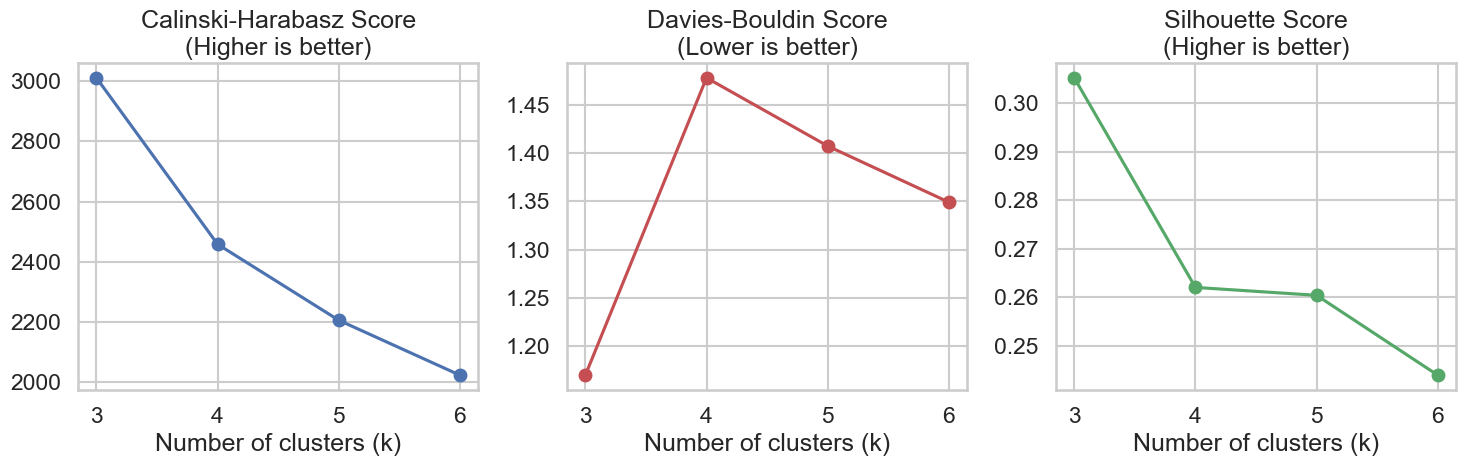

Optimal k according to Calinski-Harabasz (Max): 3
Optimal k according to Davies-Bouldin (Min): 3
Optimal k according to Silhouette (Max): 3


In [35]:
#4 Choose the best number of cluster

# Define the range of k values you want to test
k_values = range(3, 7) # Testing k from 2 to 10

# Initialize lists to store the metrics
ch_scores = []
db_scores = []
sil_scores = []
cluster_results = {} # To save labels for the optimal choice later

# Calculate metrics for each k
print("Evaluating clusters in FAMD space...")
for k in k_values:
    # Run KMeans on the FAMD data
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_famd)
    cluster_results[k] = labels
    
    # Calculate and store the three scores (Defaulting to Euclidean distance on X_famd)
    ch_scores.append(calinski_harabasz_score(X_famd, labels))
    db_scores.append(davies_bouldin_score(X_famd, labels))
    sil_scores.append(silhouette_score(X_famd, labels))

# Plot evaluation metrics (Professor's visual layout)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Calinski-Harabasz (Higher is better)
ax1.plot(k_values, ch_scores, 'bo-')
ax1.set_title('Calinski-Harabasz Score\n(Higher is better)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_xticks(k_values)
ax1.grid(True)

# Davies-Bouldin (Lower is better)
ax2.plot(k_values, db_scores, 'ro-')
ax2.set_title('Davies-Bouldin Score\n(Lower is better)')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_xticks(k_values)
ax2.grid(True)

# Silhouette (Higher is better)
ax3.plot(k_values, sil_scores, 'go-')
ax3.set_title('Silhouette Score\n(Higher is better)')
ax3.set_xlabel('Number of clusters (k)')
ax3.set_xticks(k_values)
ax3.grid(True)

plt.tight_layout()
plt.show()

# Print optimal values automatically
best_ch_k = k_values[np.argmax(ch_scores)]
best_db_k = k_values[np.argmin(db_scores)]
best_sil_k = k_values[np.argmax(sil_scores)]

print(f"Optimal k according to Calinski-Harabasz (Max): {best_ch_k}")
print(f"Optimal k according to Davies-Bouldin (Min): {best_db_k}")
print(f"Optimal k according to Silhouette (Max): {best_sil_k}")

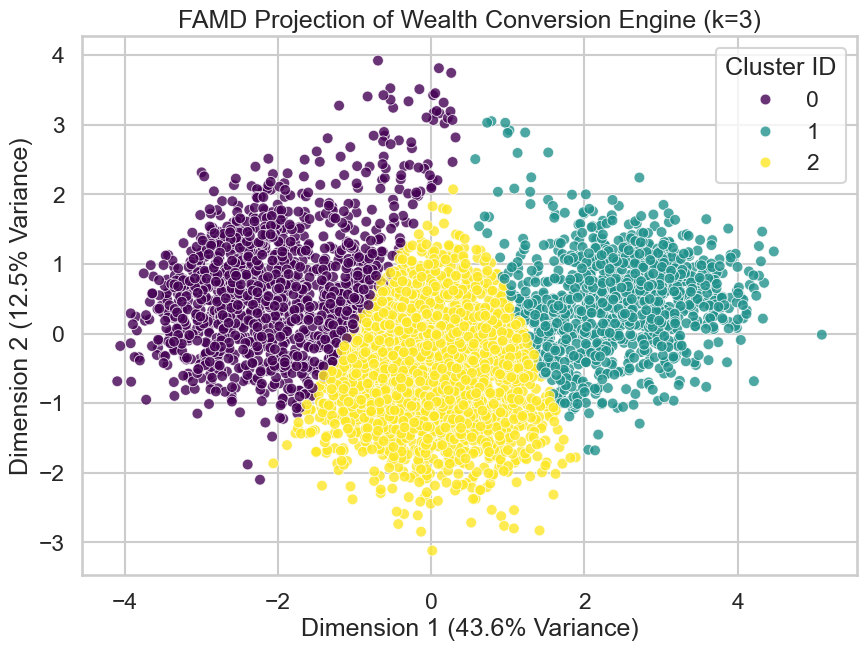


--- CLUSTER PROFILES (The Business Truth) ---


,Wealth,Income,Debt,Saving,Luxury,LifeStyle,Investments
Cluster_ID,,,,,,,
0,0.77,0.78,0.55,0.57,0.75,0.70,3
1,0.37,0.37,0.16,0.30,0.24,0.27,2
2,0.57,0.56,0.48,0.59,0.43,0.42,3


In [36]:
# 5. Plot the Manifold (Updated labels)
optimal_k = 3
kmeans = KMeans(optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_famd)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_famd['Dim_1'], 
    y=X_famd['Dim_2'], 
    hue=cluster_labels, 
    palette='viridis', 
    s=60, alpha=0.8
)

plt.title(f'FAMD Projection of Wealth Conversion Engine (k={optimal_k})')
plt.xlabel(f'Dimension 1 ({explained_variance[0]:.1f}% Variance)')
plt.ylabel(f'Dimension 2 ({explained_variance[1]:.1f}% Variance)')
plt.legend(title='Cluster ID')
plt.show()

# 6. Profile the Clusters to find the Business Target
df_active_mixed['Cluster_ID'] = cluster_labels
print("\n--- CLUSTER PROFILES (The Business Truth) ---")
display(df_active_mixed.groupby('Cluster_ID').agg({
    'Wealth': 'mean',
    'Income': 'mean',
    'Debt': 'mean',
    'Saving': 'mean',
    'Luxury': 'mean',
    'LifeStyle':'mean',
    'Investments': lambda x: x.mode()[0]
}).round(2))

In [37]:
# 1. Extract the column contributions to each FAMD dimension
contributions = famd.column_contributions_.style.format("{:.2%}")
print("--- FEATURE CONTRIBUTIONS TO FAMD DIMENSIONS ---")
display(contributions)

# 2. Extract column correlations (for continuous variables)
# This tells you the direction (positive/negative correlation)
try:
    # 1. Get the FAMD coordinates (the components/scores)
    row_coordinates = famd.transform(df_active_mixed)

    # 2. Identify your numerical columns
    # (FAMD correlations are typically only meaningful for continuous data)
    numerical_cols = df_active_mixed.select_dtypes(include=['number']).columns

    # 3. Calculate correlation between original numerical data and FAMD dimensions
    correlations = df_active_mixed[numerical_cols].apply(lambda x: row_coordinates.corrwith(x))

    print("\n--- FEATURE CORRELATIONS WITH DIMENSIONS (MANUAL) ---")
    display(correlations.round(3))
except AttributeError:
    pass # Older versions of Prince might handle this differently

--- FEATURE CONTRIBUTIONS TO FAMD DIMENSIONS ---


component,0,1,2,3
variable,,,,
Wealth,17.38%,2.12%,29.83%,30.96%
Income,17.84%,3.33%,2.91%,63.81%
Debt,15.52%,19.86%,21.92%,0.77%
Saving,12.17%,46.43%,7.61%,0.16%
Luxury,19.57%,11.14%,0.07%,0.02%
LifeStyle,16.60%,12.32%,29.16%,4.07%
Investments,1.84%,9.58%,16.99%,0.43%



--- FEATURE CORRELATIONS WITH DIMENSIONS (MANUAL) ---


,Wealth,Income,Debt,Saving,Luxury,LifeStyle,Cluster_ID
component,,,,,,,
0,-0.728,-0.738,-0.688,-0.609,-0.772,-0.711,0.364
1,0.136,0.171,-0.417,-0.637,0.312,0.328,-0.546
2,0.430,0.134,-0.369,0.217,0.021,-0.425,0.020
3,-0.413,0.593,-0.065,0.030,-0.010,-0.150,0.006


In [38]:
# df_active_original should be your raw Wealth, Income, Debt, Saving, Investments data
df_active_mixed['Cluster_ID'] = cluster_labels

print("--- THE FINANCIAL PERSONAS (Averages by Cluster) ---")
profile_active = df_active_mixed.groupby('Cluster_ID').agg({
    'Wealth': 'mean',
    'Income': 'mean',
    'Debt': 'mean',
    'Saving': 'mean',
    'Luxury': 'mean',
    'LifeStyle': 'mean',
    'Investments': lambda x: x.mode()[0] # The most frequent investment level
}).round(1)

display(profile_active)

--- THE FINANCIAL PERSONAS (Averages by Cluster) ---


,Wealth,Income,Debt,Saving,Luxury,LifeStyle,Investments
Cluster_ID,,,,,,,
0,0.8,0.8,0.6,0.6,0.8,0.7,3
1,0.4,0.4,0.2,0.3,0.2,0.3,2
2,0.6,0.6,0.5,0.6,0.4,0.4,3


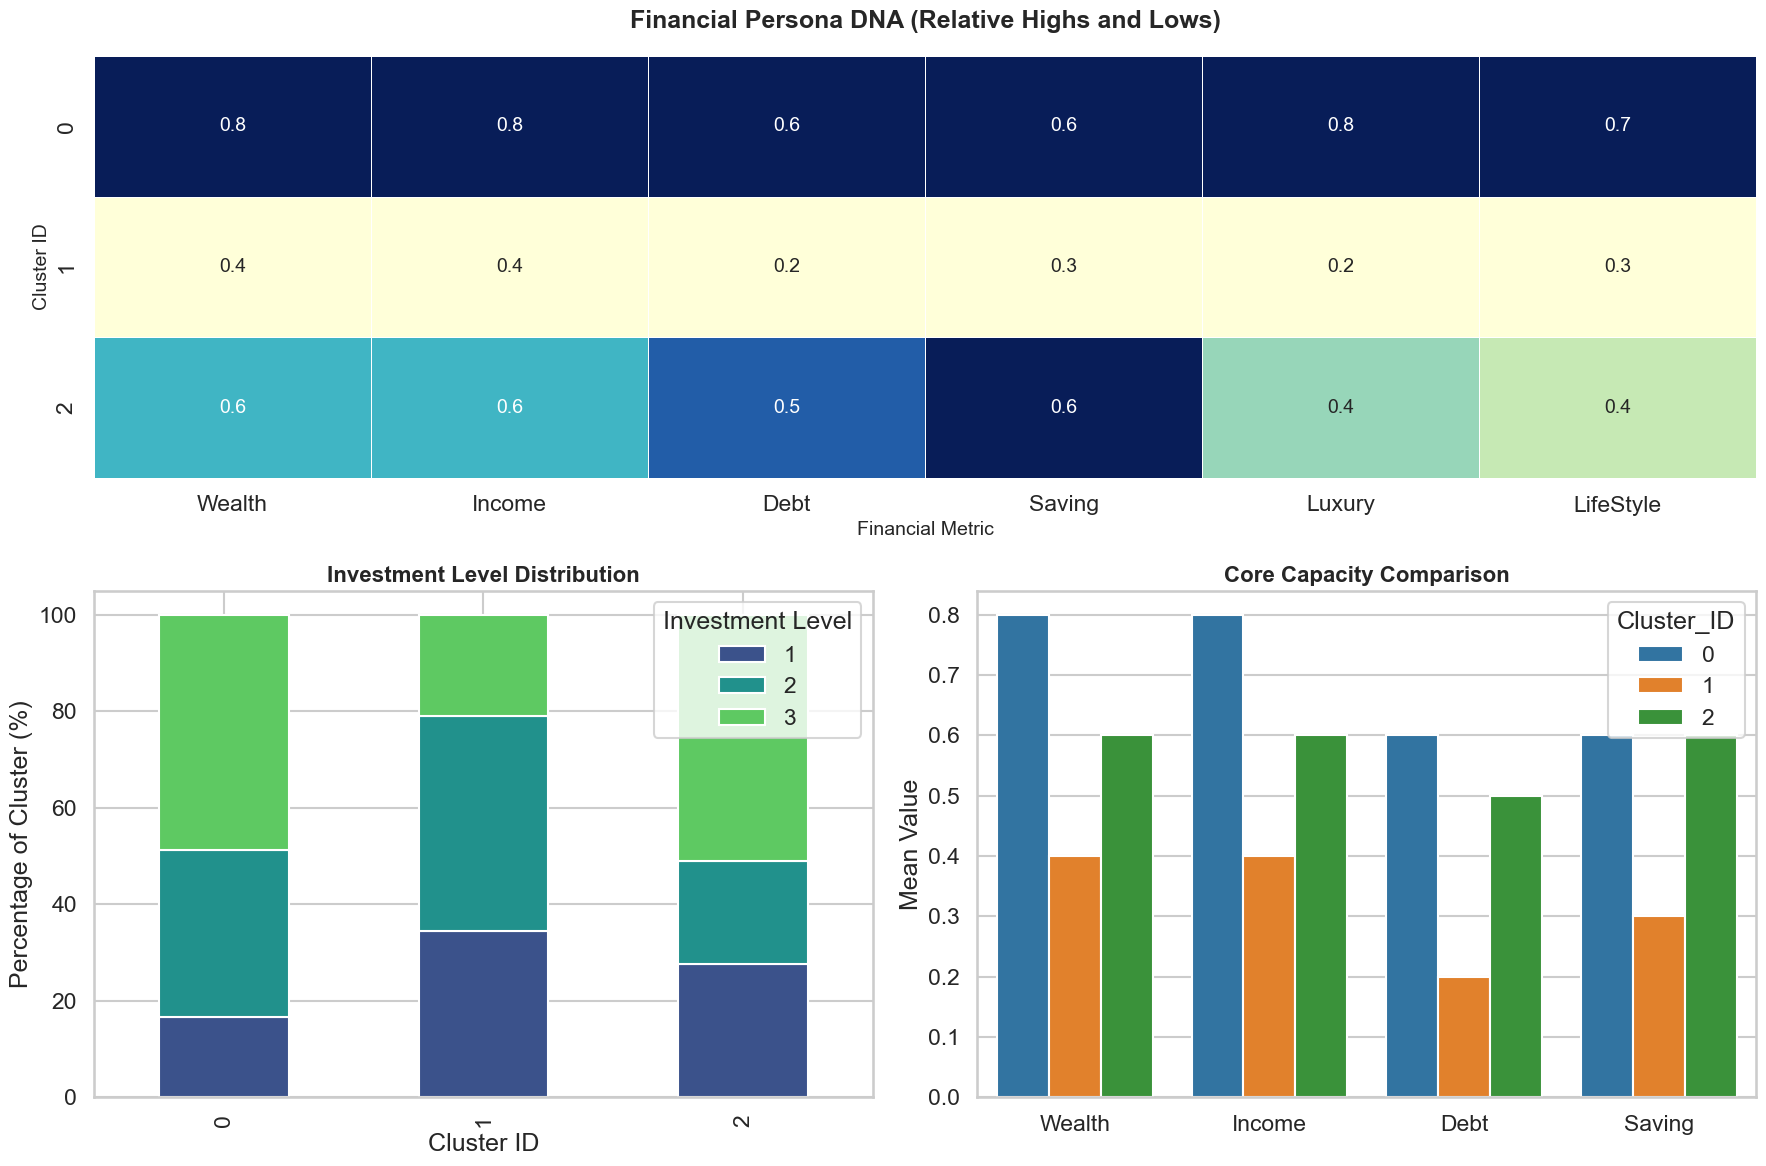

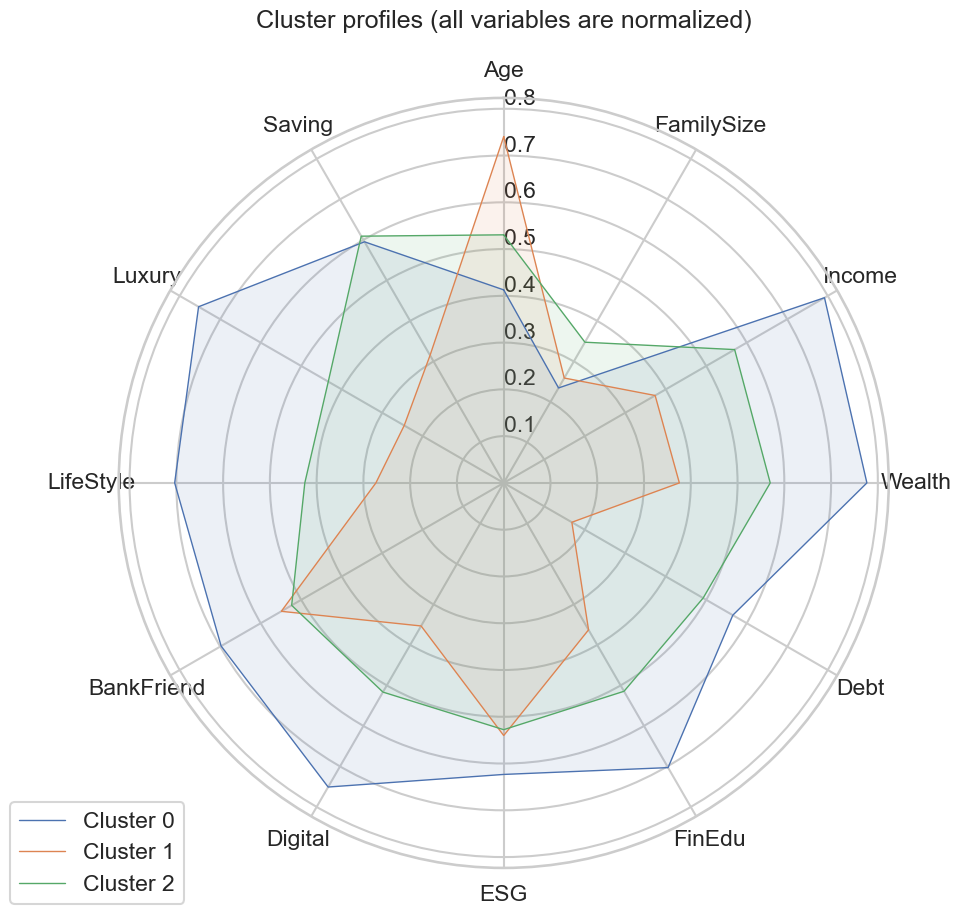

In [39]:
# 1. Prepare the Data
# We exclude 'Investments' for the heatmap because it's categorical
num_profile = profile_active.drop(columns=['Investments'])

# Scale the means (0 to 1) just for the heatmap colors to ensure 
# high values are dark and low values are light across different scales.
scaler = MinMaxScaler()
scaled_profile = pd.DataFrame(
    scaler.fit_transform(num_profile), 
    columns=num_profile.columns, 
    index=num_profile.index
)

# ==========================================
# FINANCIAL PERSONA DASHBOARD
# ==========================================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# A. THE HEATMAP (The "Pattern" View)
ax0 = fig.add_subplot(gs[0, :])
sns.heatmap(scaled_profile, annot=num_profile, fmt=".1f", cmap="YlGnBu", 
            cbar=False, linewidths=.5, ax=ax0, annot_kws={"size": 14})
ax0.set_title("Financial Persona DNA (Relative Highs and Lows)", fontsize=18, fontweight='bold', pad=20)
ax0.set_xlabel("Financial Metric", fontsize=14)
ax0.set_ylabel("Cluster ID", fontsize=14)

# B. THE CATEGORICAL TARGET (Investments Level)
ax1 = fig.add_subplot(gs[1, 0])
# We look at the actual distribution of Investments for each cluster
inv_dist = pd.crosstab(df_active_mixed['Cluster_ID'], df_active_mixed['Investments'], normalize='index') * 100
inv_dist.plot(kind='bar', stacked=True, ax=ax1, color=sns.color_palette("viridis", 3))
ax1.set_title("Investment Level Distribution", fontsize=16, fontweight='bold')
ax1.set_ylabel("Percentage of Cluster (%)")
ax1.set_xlabel("Cluster ID")
ax1.legend(title="Investment Level", loc='upper right')

# C. THE COMPARISON (Wealth vs. Income vs. Debt)
ax2 = fig.add_subplot(gs[1, 1])
# Melting for a grouped bar chart
melted_active = num_profile[['Wealth', 'Income', 'Debt', 'Saving']].reset_index().melt(id_vars='Cluster_ID')
sns.barplot(data=melted_active, x='variable', y='value', hue='Cluster_ID', ax=ax2, palette='tab10')
ax2.set_title("Core Capacity Comparison", fontsize=16, fontweight='bold')
ax2.set_ylabel("Mean Value")
ax2.set_xlabel("")

plt.tight_layout()
plt.show()

# ==========================================
# RADAR CHART (Spider Plot) FOR ALL VARIABLES
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

radar_cols = ['Age', 'FamilySize', 'Income', 'Wealth', 'Debt', 'FinEdu', 'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving']
data_with_clusters = data.copy()
data_with_clusters['Cluster'] = cluster_labels

def plot_cluster_radar(data):
    # Create a copy of the data for normalization
    plot_data = data.copy()
    
    # Normalize all numerical variables using MinMaxScaler
    scaler = MinMaxScaler()
    plot_data[radar_cols] = scaler.fit_transform(plot_data[radar_cols])
    
    # Calculate mean values for each numerical variable by cluster
    cluster_means = plot_data.groupby('Cluster')[radar_cols].mean()
    
    # Set up the radar chart
    categories = radar_cols
    num_vars = len(categories)
    angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    # Plot for each cluster
    for cluster in range(3):
        values = cluster_means.loc[cluster].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=1, linestyle='solid', label=f'Cluster {cluster}')
        ax.fill(angles, values, alpha=0.1)
    
    # Set chart properties
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(0)
    plt.xticks(angles[:-1], categories)
    ax.set_title("Cluster profiles (all variables are normalized)", y=1.08)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    
    plt.show()

# Execute visualizations
plot_cluster_radar(data_with_clusters)


In [40]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 0
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Most common familySize : {target_profile['FamilySize'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Job: {target_profile['Job'].mode()[0]}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_cluster_id = 0
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

# ... (Insert the distribution code from the previous step here)

--- MARKETING PROFILE FOR TARGET CLUSTER 0 ---
Average Age: 50.4
Most common Gender: 0
Most common familySize : 1
Digital Propensity: 0.73
BankFriend Propensity: 0.72
Financial Education: 0.68
Most common Job: 2
Most common Area: 1
Most common CitySize: 3
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 0 ---

--- Gender Distribution ---
Gender
0    52.7%
1    47.3%
Name: proportion, dtype: object

--- Job Distribution ---
Job
2    76.4%
1    12.2%
3     5.2%
5     3.9%
4     2.3%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    80.4%
2    13.1%
3     6.5%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
3    56.1%
2    31.8%
1    12.1%
Name: proportion, dtype: object

--- FamilySize Distribution ---
FamilySize
1    40.9%
2    24.6%
3    16.4%
4    14.2%
5     2.5%
6     1.5%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  50.369842  0.729671    0.721374  0.676584
min   19.00

/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_14717/1992887353.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2')


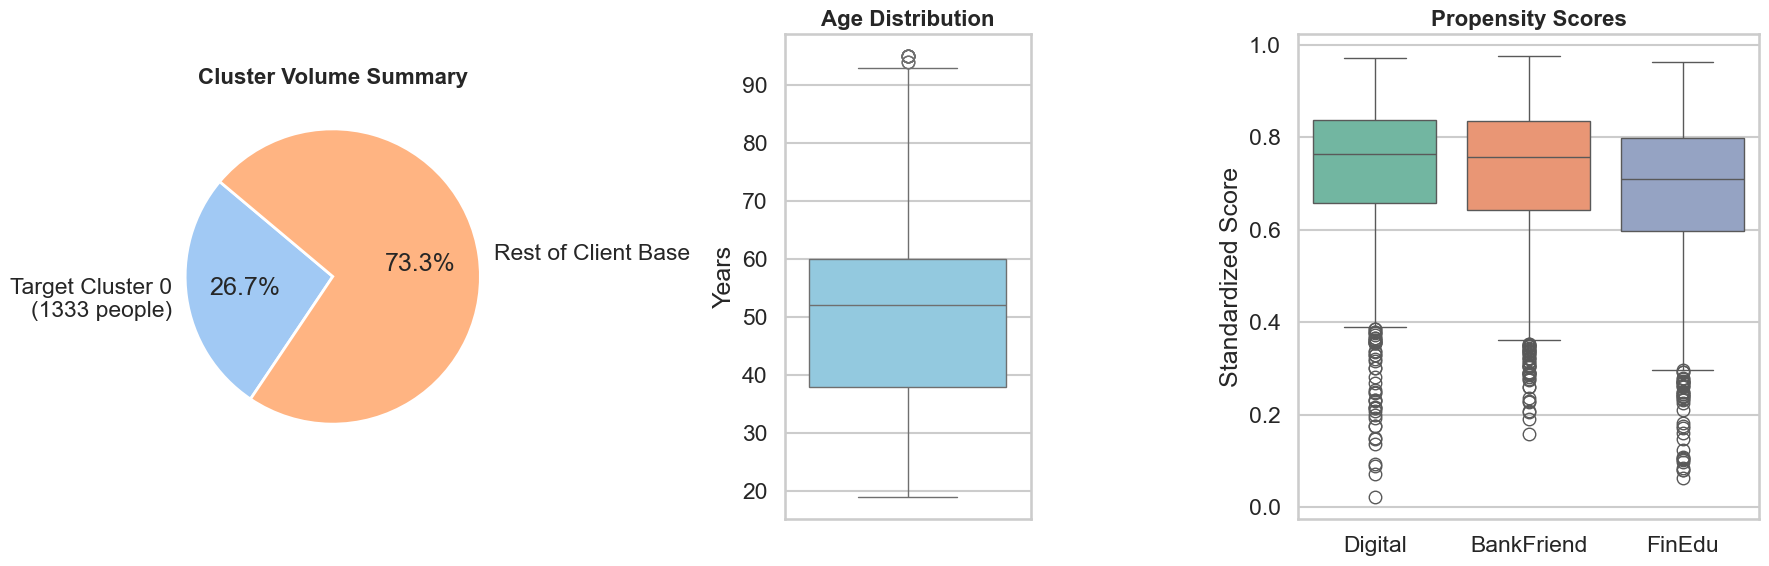

/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_14717/1992887353.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h')
/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_14717/1992887353.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h')
/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_14717/1992887353.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.values, y

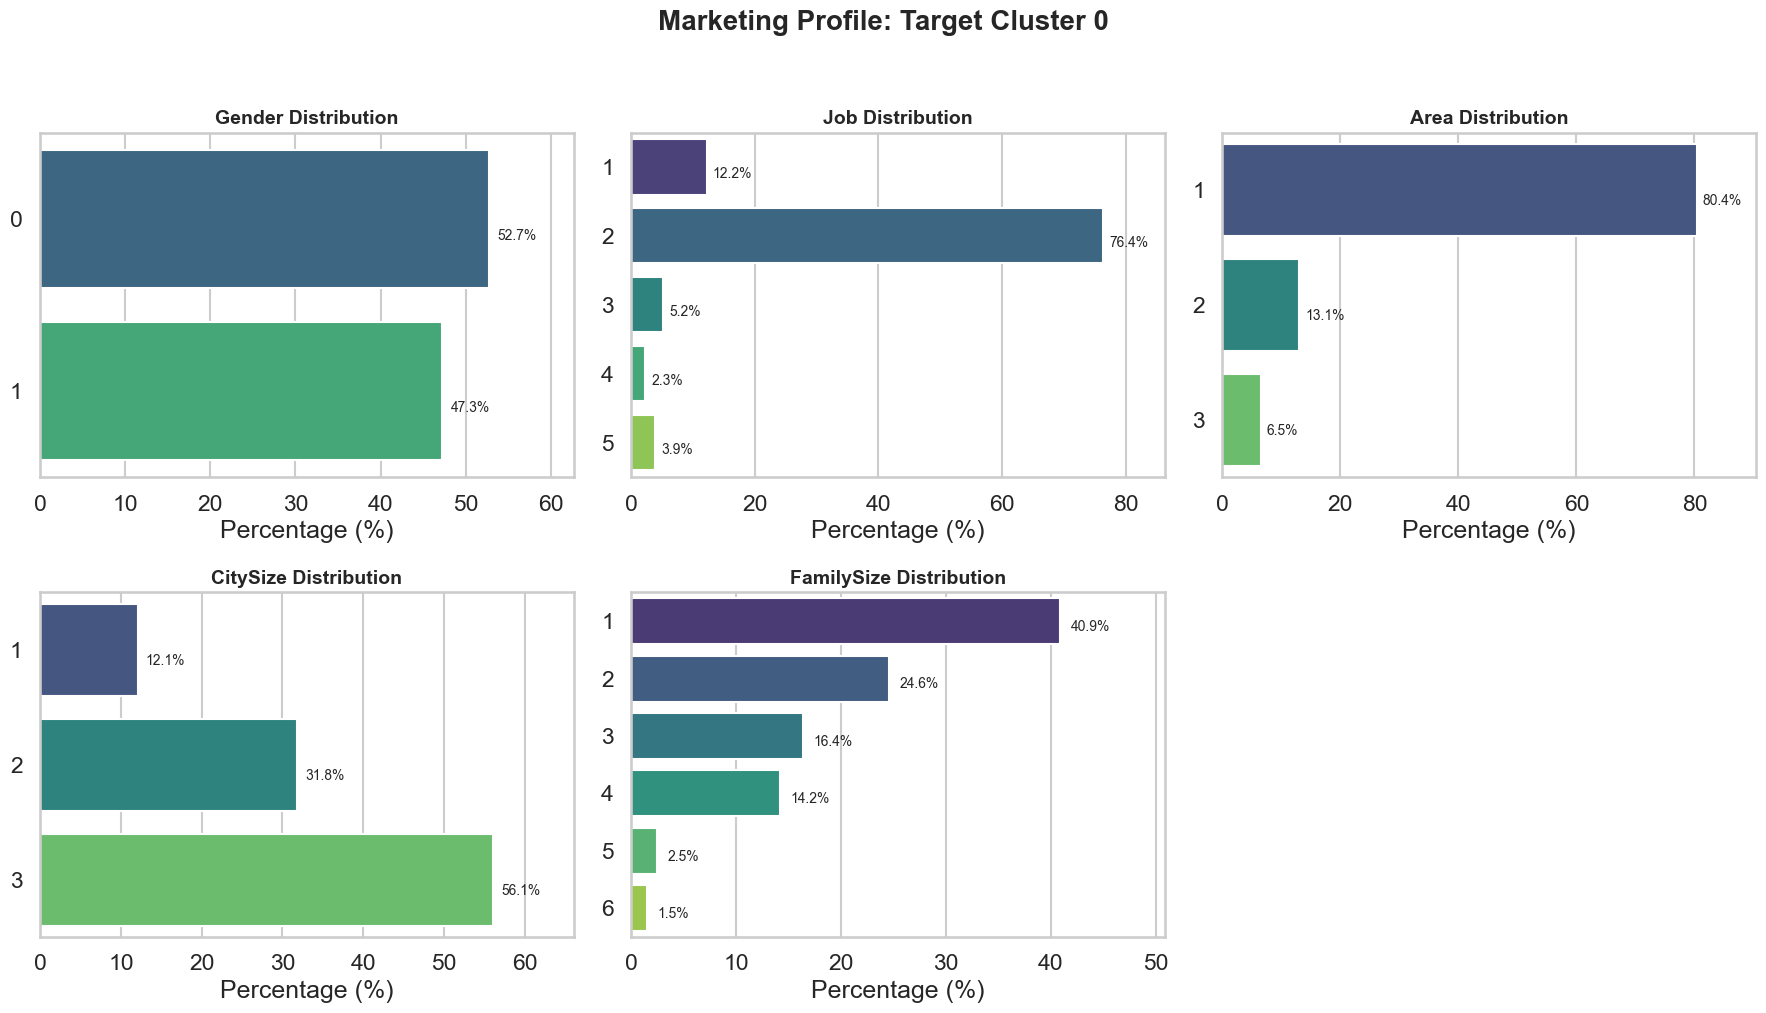

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the visual style for the dashboard
sns.set_theme(style="whitegrid", context="talk")

# --- Setup Variables ---
# (Assuming target_cluster_id and target_profile are already defined)
total_count = len(df_passive_obj1)
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

# ==========================================
# DASHBOARD PART 1: VOLUME & NUMERICAL TRAITS
# ==========================================
# We changed this to 3 columns: Pie Chart, Age Plot, Propensity Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.2, 0.8, 1.5]})

# 1A. Pie Chart for Volume
labels = [f'Target Cluster {target_cluster_id}\n({cluster_count} people)', 'Rest of Client Base']
sizes = [cluster_count, total_count - cluster_count]
colors = sns.color_palette('pastel')[0:2]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f"Cluster Volume Summary", fontsize=16, fontweight='bold')

# 1B. Boxplot strictly for AGE
sns.boxplot(data=target_profile, y='Age', ax=axes[1], color='skyblue')
axes[1].set_title("Age Distribution", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Years")

# 1C. Boxplots strictly for STANDARDIZED SCORES
scaled_cols = ['Digital', 'BankFriend', 'FinEdu']
melted_scaled = target_profile[scaled_cols].melt(var_name='Feature', value_name='Score')

sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2')
axes[2].set_title("Propensity Scores", fontsize=16, fontweight='bold')
axes[2].set_xlabel("")
axes[2].set_ylabel("Standardized Score")

plt.tight_layout()
plt.show()


# ==========================================
# DASHBOARD PART 2: CATEGORICAL DISTRIBUTIONS
# ==========================================
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

# Create a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten to easily loop through them

for i, col in enumerate(cat_cols):
    # Calculate percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    
    # Create Horizontal Bar Plot
    sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h')
    
    # Formatting
    axes[i].set_title(f"{col} Distribution", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, max(dist.values) + 10) # Give a little breathing room on the right
    
    # Add exact percentage text labels onto the bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width + 1, p.get_y() + p.get_height()/2. + 0.1, 
                     f'{width:.1f}%', ha="left", va="center", fontsize=10)

# Hide the 6th empty subplot (since we only have 5 categorical columns)
axes[5].axis('off')

fig.suptitle(f"Marketing Profile: Target Cluster {target_cluster_id}", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [42]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 1
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Most common familySize : {target_profile['FamilySize'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Job: {target_profile['Job'].mode()[0]}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 1 ---
Average Age: 75.3
Most common Gender: 1
Most common familySize : 1
Digital Propensity: 0.34
BankFriend Propensity: 0.60
Financial Education: 0.35
Most common Job: 5
Most common Area: 1
Most common CitySize: 2
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 1 ---

--- Gender Distribution ---
Gender
1    54.9%
0    45.1%
Name: proportion, dtype: object

--- Job Distribution ---
Job
5    58.8%
2    19.8%
1    18.2%
4     2.4%
3     0.7%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    66.5%
2    23.4%
3    10.1%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    47.6%
1    43.2%
3     9.2%
Name: proportion, dtype: object

--- FamilySize Distribution ---
FamilySize
1    33.5%
2    27.5%
3    20.1%
4    15.0%
5     2.5%
6     1.4%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  75.281335  0.343238    0.597049  0.349228
min   19.00

/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_14717/1992887353.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2')


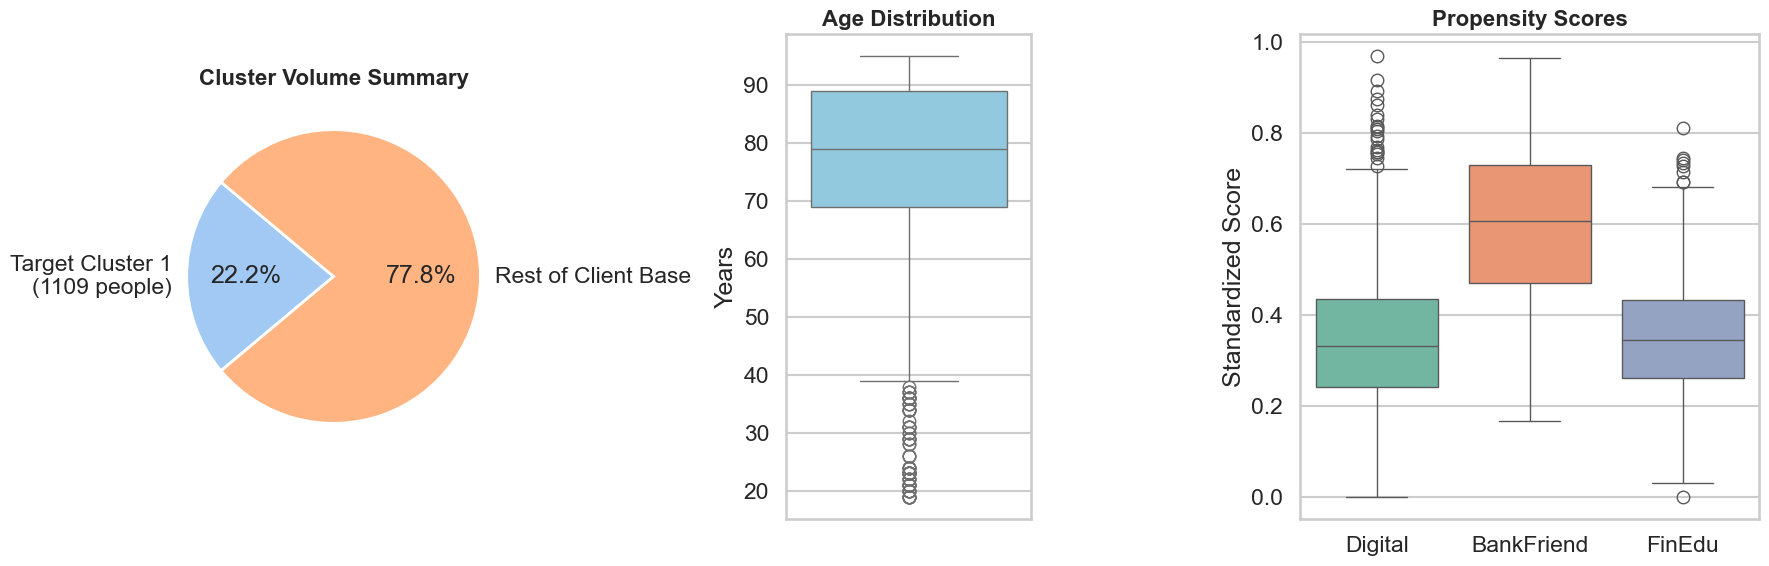

/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_14717/1992887353.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h')
/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_14717/1992887353.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h')
/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_14717/1992887353.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.values, y

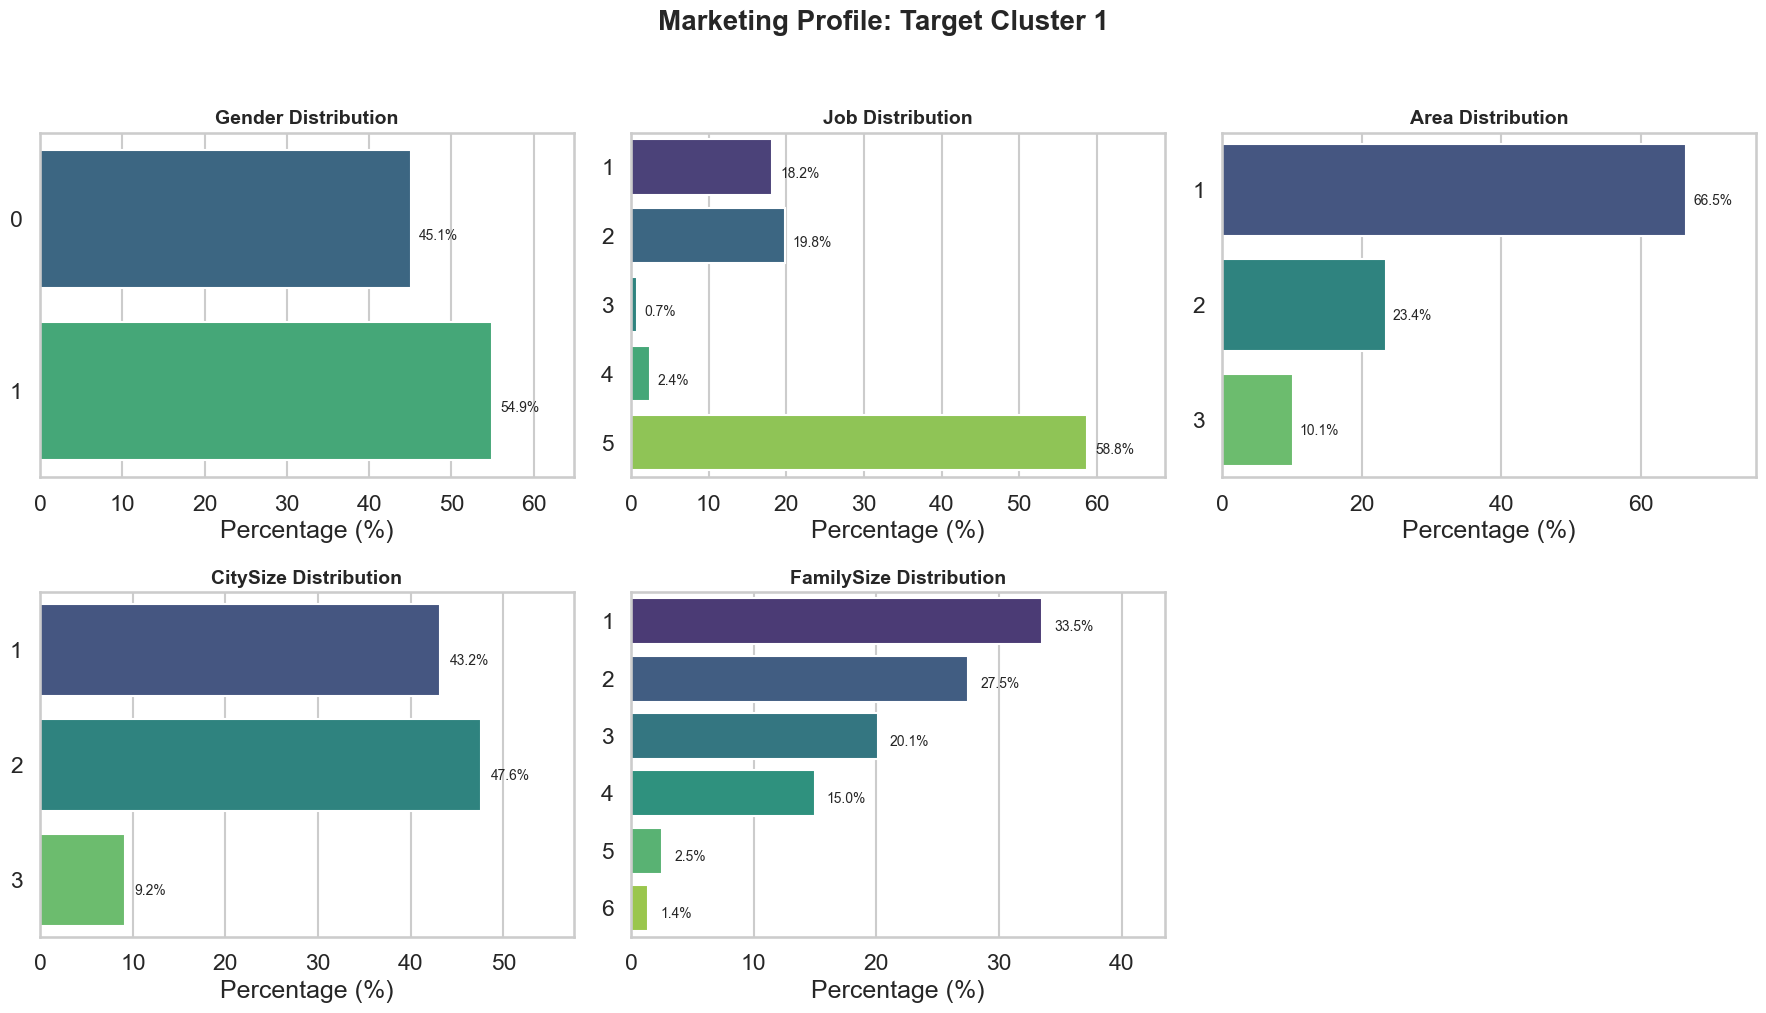

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the visual style for the dashboard
sns.set_theme(style="whitegrid", context="talk")

# --- Setup Variables ---
# (Assuming target_cluster_id and target_profile are already defined)
total_count = len(df_passive_obj1)
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

# ==========================================
# DASHBOARD PART 1: VOLUME & NUMERICAL TRAITS
# ==========================================
# We changed this to 3 columns: Pie Chart, Age Plot, Propensity Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.2, 0.8, 1.5]})

# 1A. Pie Chart for Volume
labels = [f'Target Cluster {target_cluster_id}\n({cluster_count} people)', 'Rest of Client Base']
sizes = [cluster_count, total_count - cluster_count]
colors = sns.color_palette('pastel')[0:2]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f"Cluster Volume Summary", fontsize=16, fontweight='bold')

# 1B. Boxplot strictly for AGE
sns.boxplot(data=target_profile, y='Age', ax=axes[1], color='skyblue')
axes[1].set_title("Age Distribution", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Years")

# 1C. Boxplots strictly for STANDARDIZED SCORES
scaled_cols = ['Digital', 'BankFriend', 'FinEdu']
melted_scaled = target_profile[scaled_cols].melt(var_name='Feature', value_name='Score')

sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2')
axes[2].set_title("Propensity Scores", fontsize=16, fontweight='bold')
axes[2].set_xlabel("")
axes[2].set_ylabel("Standardized Score")

plt.tight_layout()
plt.show()


# ==========================================
# DASHBOARD PART 2: CATEGORICAL DISTRIBUTIONS
# ==========================================
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

# Create a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten to easily loop through them

for i, col in enumerate(cat_cols):
    # Calculate percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    
    # Create Horizontal Bar Plot
    sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h')
    
    # Formatting
    axes[i].set_title(f"{col} Distribution", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, max(dist.values) + 10) # Give a little breathing room on the right
    
    # Add exact percentage text labels onto the bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width + 1, p.get_y() + p.get_height()/2. + 0.1, 
                     f'{width:.1f}%', ha="left", va="center", fontsize=10)

# Hide the 6th empty subplot (since we only have 5 categorical columns)
axes[5].axis('off')

fig.suptitle(f"Marketing Profile: Target Cluster {target_cluster_id}", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [44]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 2
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Most common familySize : {target_profile['FamilySize'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Job: {target_profile['Job'].mode()[0]}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 2 ---
Average Age: 59.3
Most common Gender: 1
Most common familySize : 1
Digital Propensity: 0.50
BankFriend Propensity: 0.58
Financial Education: 0.50
Most common Job: 2
Most common Area: 1
Most common CitySize: 2
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 2 ---

--- Gender Distribution ---
Gender
1    54.8%
0    45.2%
Name: proportion, dtype: object

--- Job Distribution ---
Job
2    80.0%
1     9.5%
5     6.0%
3     2.6%
4     1.9%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    71.0%
2    15.2%
3    13.8%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    43.4%
1    39.6%
3    17.0%
Name: proportion, dtype: object

--- FamilySize Distribution ---
FamilySize
1    27.0%
2    22.2%
3    21.8%
4    14.4%
5     8.2%
6     6.4%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  59.315955  0.501872    0.575683  0.495183
min   19.00

/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_14717/1992887353.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2')


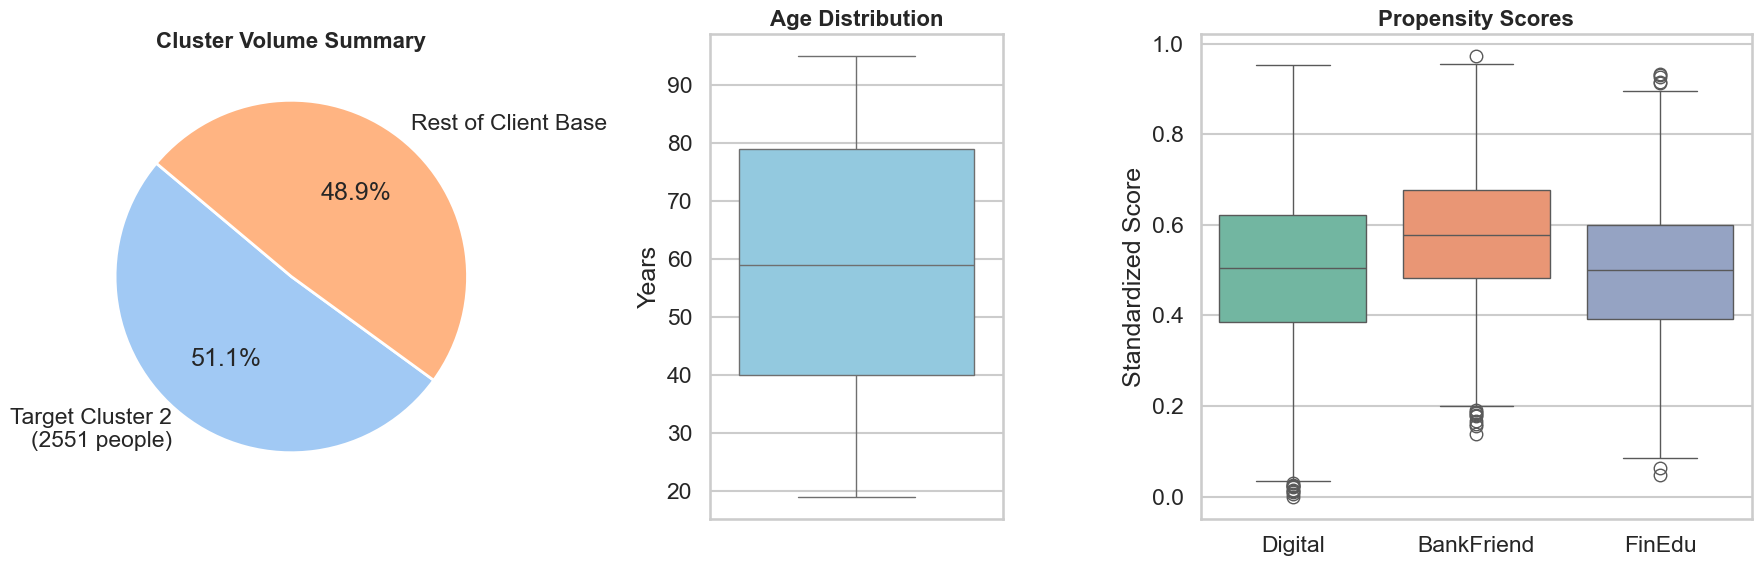

/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_14717/1992887353.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h')
/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_14717/1992887353.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h')
/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_14717/1992887353.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.values, y

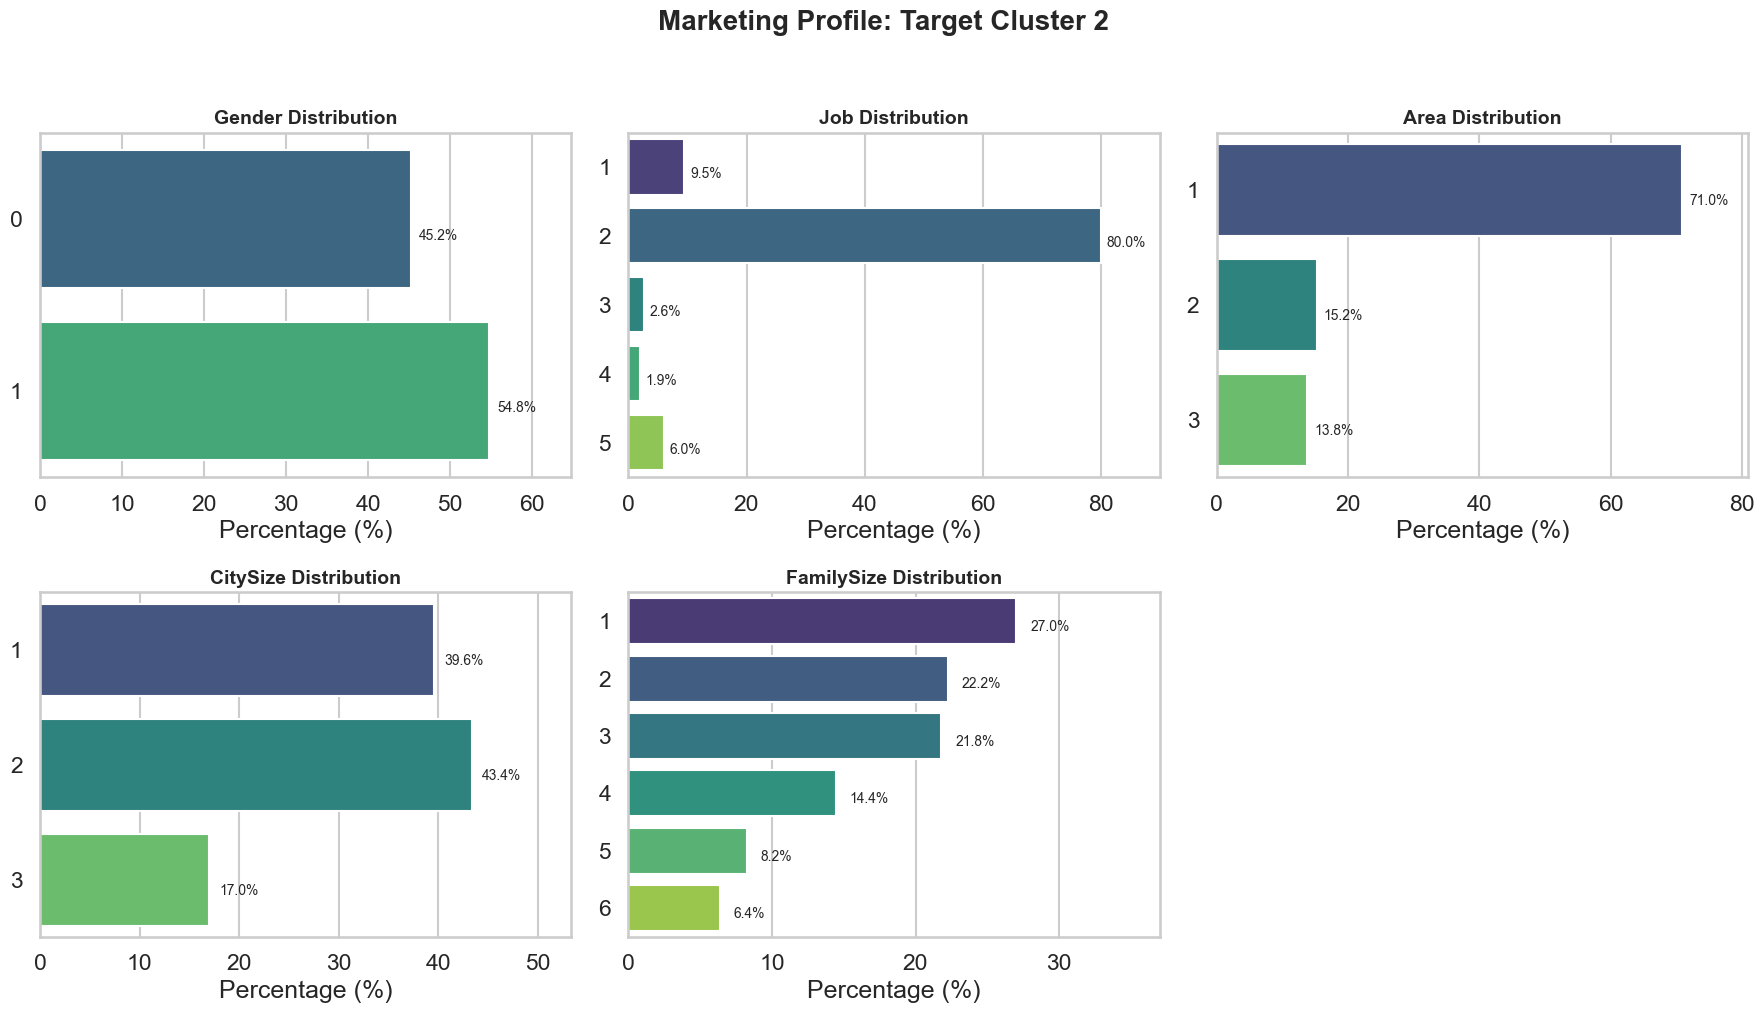

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the visual style for the dashboard
sns.set_theme(style="whitegrid", context="talk")

# --- Setup Variables ---
# (Assuming target_cluster_id and target_profile are already defined)
total_count = len(df_passive_obj1)
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

# ==========================================
# DASHBOARD PART 1: VOLUME & NUMERICAL TRAITS
# ==========================================
# We changed this to 3 columns: Pie Chart, Age Plot, Propensity Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.2, 0.8, 1.5]})

# 1A. Pie Chart for Volume
labels = [f'Target Cluster {target_cluster_id}\n({cluster_count} people)', 'Rest of Client Base']
sizes = [cluster_count, total_count - cluster_count]
colors = sns.color_palette('pastel')[0:2]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f"Cluster Volume Summary", fontsize=16, fontweight='bold')

# 1B. Boxplot strictly for AGE
sns.boxplot(data=target_profile, y='Age', ax=axes[1], color='skyblue')
axes[1].set_title("Age Distribution", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Years")

# 1C. Boxplots strictly for STANDARDIZED SCORES
scaled_cols = ['Digital', 'BankFriend', 'FinEdu']
melted_scaled = target_profile[scaled_cols].melt(var_name='Feature', value_name='Score')

sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2')
axes[2].set_title("Propensity Scores", fontsize=16, fontweight='bold')
axes[2].set_xlabel("")
axes[2].set_ylabel("Standardized Score")

plt.tight_layout()
plt.show()


# ==========================================
# DASHBOARD PART 2: CATEGORICAL DISTRIBUTIONS
# ==========================================
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

# Create a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten to easily loop through them

for i, col in enumerate(cat_cols):
    # Calculate percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    
    # Create Horizontal Bar Plot
    sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h')
    
    # Formatting
    axes[i].set_title(f"{col} Distribution", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, max(dist.values) + 10) # Give a little breathing room on the right
    
    # Add exact percentage text labels onto the bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width + 1, p.get_y() + p.get_height()/2. + 0.1, 
                     f'{width:.1f}%', ha="left", va="center", fontsize=10)

# Hide the 6th empty subplot (since we only have 5 categorical columns)
axes[5].axis('off')

fig.suptitle(f"Marketing Profile: Target Cluster {target_cluster_id}", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()